## Lagrangian mechanics of the double pendolum

The double pendolum is an evergreen problem that every student must solve once in a lifetime

<img src="https://galileo-unbound.blog/wp-content/uploads/2020/10/compoundpendulum.jpg?w=2400" width="75%" style="display:block; margin-left:auto; margin-right:auto;">

In [1]:
# Packages
import sympy as smp
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sb

In [2]:
# Symbols and functions
m1, m2, g, R1, R2 = smp.symbols('m_1 m_2 g R_1 R_2', real = True, positive = True, constant = True) # Constant values
t = smp.symbols('t', real = True, nonnegative = True)

theta1 = smp.Function('theta_1', real = True)(t) # First angle
theta2 = smp.Function('theta_2', real = True)(t) # Second angle

The Cartesian positions of the masses are:

$$
    x_1 = R_1 \sin\theta_1 \quad
    y_1 = -R_1 \cos\theta_1 \quad
    x_2 = R_1 \sin\theta_1 + R_2 \sin\theta_2 \quad
    y_2 = -R_1 \cos\theta_1 - R_2 \cos\theta_2
$$

In [3]:
# Positions of the masses
x1 = R1 * smp.sin(theta1)
y1 = - R1 * smp.cos(theta1)

x2 = R1 * smp.sin(theta1) + R2 * smp.sin(theta2)
y2 = - R1 * smp.cos(theta1) - R2 * smp.cos(theta2)

The lagrangian $\mathcal{L}$ of a given system is just the difference between its kinetic energy $T$ with its potential energy $V$

In [4]:
# Computing the lagrangian of the system
T = smp.Rational(1, 2) * m1 * (smp.diff(x1, t, 1) ** 2 + smp.diff(y1, t, 1) ** 2) + smp.Rational(1, 2) * m2 * (smp.diff(x2, t, 1) ** 2 + smp.diff(y2, t, 1) ** 2) # Kinetic energy
V = m1 * g * y1 + m2 * g * y2 # Potential energy

L = (T - V).trigsimp() # Lagrangian
L

R_1**2*m_1*Derivative(theta_1(t), t)**2/2 + R_1*g*m_1*cos(theta_1(t)) + g*m_2*(R_1*cos(theta_1(t)) + R_2*cos(theta_2(t))) + m_2*(R_1**2*Derivative(theta_1(t), t)**2 + 2*R_1*R_2*cos(theta_1(t) - theta_2(t))*Derivative(theta_1(t), t)*Derivative(theta_2(t), t) + R_2**2*Derivative(theta_2(t), t)**2)/2

The Euler-Lagrange equations for each generalized coordinate $q$ are:

$$
\frac{d}{dt} \left( \frac{\partial \mathcal{L}}{\partial \dot{q}} \right) - \frac{\partial \mathcal{L}}{\partial q} = 0
$$

In our problem, $q = \theta_1 ,\, \theta_2$

In [5]:
# Euler-lagrangian equations
euler_lagrange_equations = smp.calculus.euler_equations(L, funcs = [theta1, theta2], vars = t) # Using sympy.calculus.euler_equations() built-in
euler_lagrange_equations = [equation.simplify() for equation in euler_lagrange_equations]
euler_lagrange_equations

[Eq(R_1*(R_1*m_1*Derivative(theta_1(t), (t, 2)) + R_1*m_2*Derivative(theta_1(t), (t, 2)) + R_2*m_2*sin(theta_1(t) - theta_2(t))*Derivative(theta_2(t), t)**2 + R_2*m_2*cos(theta_1(t) - theta_2(t))*Derivative(theta_2(t), (t, 2)) + g*m_1*sin(theta_1(t)) + g*m_2*sin(theta_1(t))), 0),
 Eq(R_2*m_2*(R_1*sin(theta_1(t) - theta_2(t))*Derivative(theta_1(t), t)**2 - R_1*cos(theta_1(t) - theta_2(t))*Derivative(theta_1(t), (t, 2)) - R_2*Derivative(theta_2(t), (t, 2)) - g*sin(theta_2(t))), 0)]

In [6]:
euler_lagrange_equations[0]

Eq(R_1*(R_1*m_1*Derivative(theta_1(t), (t, 2)) + R_1*m_2*Derivative(theta_1(t), (t, 2)) + R_2*m_2*sin(theta_1(t) - theta_2(t))*Derivative(theta_2(t), t)**2 + R_2*m_2*cos(theta_1(t) - theta_2(t))*Derivative(theta_2(t), (t, 2)) + g*m_1*sin(theta_1(t)) + g*m_2*sin(theta_1(t))), 0)

In [7]:
euler_lagrange_equations[1]

Eq(R_2*m_2*(R_1*sin(theta_1(t) - theta_2(t))*Derivative(theta_1(t), t)**2 - R_1*cos(theta_1(t) - theta_2(t))*Derivative(theta_1(t), (t, 2)) - R_2*Derivative(theta_2(t), (t, 2)) - g*sin(theta_2(t))), 0)

In [8]:
# Getting the second derivatives symbolically
d_theta1_dt = smp.Derivative(theta1, t, 1)
d2_theta1_dt2 = smp.Derivative(theta1, t, 2)

d_theta2_dt = smp.Derivative(theta2, t, 1)
d2_theta2_dt2 = smp.Derivative(theta2, t, 2)

second_order_derivatives = smp.solve(euler_lagrange_equations, [d2_theta1_dt2, d2_theta2_dt2])
d2_theta1_dt2 = second_order_derivatives[d2_theta1_dt2].trigsimp()
d2_theta2_dt2 = second_order_derivatives[d2_theta2_dt2].trigsimp()

---
---
---

In [9]:
# Going numerically for SciPy
omega1 = smp.lambdify(d_theta1_dt, d_theta1_dt)
d_omega1_dt = smp.lambdify([theta1, d_theta1_dt, theta2, d_theta2_dt, m1, m2, R1, R2, g], d2_theta1_dt2)

omega2 = smp.lambdify(d_theta2_dt, d_theta2_dt)
d_omega2_dt = smp.lambdify([theta1, d_theta1_dt, theta2, d_theta2_dt, m1, m2, R1, R2, g], d2_theta2_dt2)

In [10]:
# System dSdt
def dSdt(t, S, m1, m2, R1, R2, g):
    theta1, d_theta1_dt, theta2, d_theta2_dt = S

    return [omega1(d_theta1_dt),
            d_omega1_dt(theta1, d_theta1_dt, theta2, d_theta2_dt, m1, m2, R1, R2, g),
            omega2(d_theta2_dt),
            d_omega2_dt(theta1, d_theta1_dt, theta2, d_theta2_dt, m1, m2, R1, R2, g)]

In [11]:
# Solving the system

# Time
T = 20.0 # Seconds
t = np.arange(0, T, 0.01)

# Constants
g = 9.81 # m / s^2
m1 = 1.0 # Kg
m2 = 2.0
R1 = 1.5 # m
R2 = 1.0
args = (m1, m2, R1, R2, g)

# Initial values
theta1_0 = np.pi / 3 # Rad
d_theta1_dt_0 = 0.0 # Rad/s
theta2_0 = - np.pi / 3
d_theta2_dt_0 = 0.0 
y0 = (theta1_0, d_theta1_dt_0, theta2_0, d_theta2_dt_0)

# Solve_ivp()
S = solve_ivp(fun = dSdt,
              t_span = (0, T),
              t_eval = t,
              y0 = y0,
              method = 'RK45', # Runge-Kutta 4th order method
              args = args)

In [12]:
# Stats
S

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-02 ...  1.998e+01  1.999e+01]
        y: [[ 1.047e+00  1.047e+00 ... -6.168e-01 -6.337e-01]
            [ 0.000e+00 -4.531e-02 ... -1.717e+00 -1.658e+00]
            [-1.047e+00 -1.047e+00 ...  1.347e+00  1.317e+00]
            [ 0.000e+00  5.099e-02 ... -2.973e+00 -3.075e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1502
     njev: 0
      nlu: 0

In [13]:
# Numerical solutions
theta1 = S.y[0]
d_theta1_dt = S.y[1]

theta2 = S.y[2]
d_theta2_dt = S.y[3]

x1 = R1 * np.sin(theta1)
y1 = - R1 * np.cos(theta1)

x2 = R1 * np.sin(theta1) + R2 * np.sin(theta2)
y2 = - R1 * np.cos(theta1) - R2 * np.cos(theta2)

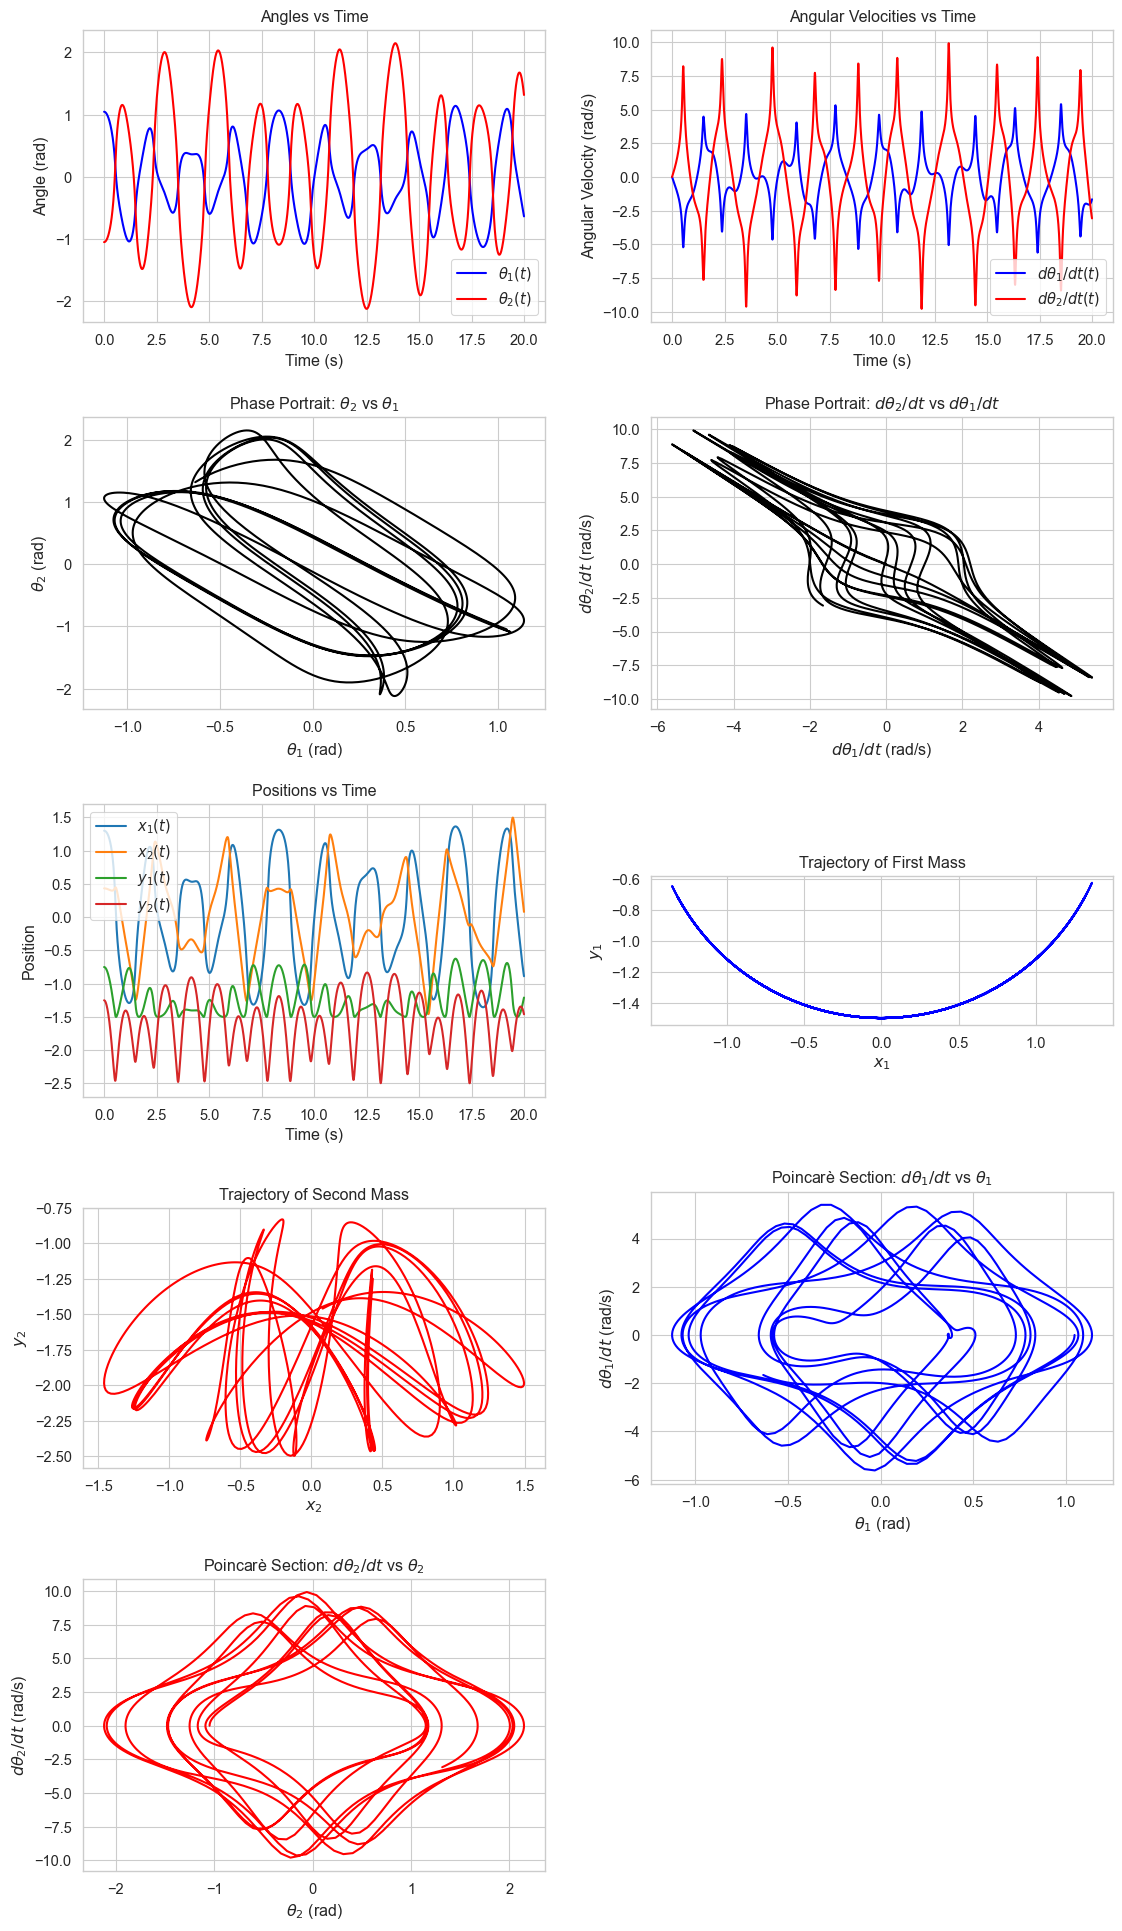

In [14]:
# Plotting all
sb.set_style("whitegrid")
sb.set_context("paper", font_scale = 1.2)

fig, axes = plt.subplots(5, 2, figsize = (12, 20))
fig.tight_layout(pad = 4.0)

# 1. Plot alpha(t) and theta(t)
axes[0, 0].plot(t, theta1, label = r'$\theta_1(t)$', linewidth = 1.5, color = 'blue')
axes[0, 0].plot(t, theta2, label = r'$\theta_2(t)$', linewidth = 1.5, color = 'red')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Angle (rad)')
axes[0, 0].legend()
axes[0, 0].set_title('Angles vs Time')

# 2. Plot d_alpha_dt(t) and d_theta_dt(t)
axes[0, 1].plot(t, d_theta1_dt, label = r'$d\theta_1/dt(t)$', linewidth = 1.5, color = 'blue')
axes[0, 1].plot(t, d_theta2_dt, label = r'$d\theta_2/dt(t)$', linewidth = 1.5, color = 'red')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Angular Velocity (rad/s)')
axes[0, 1].legend()
axes[0, 1].set_title('Angular Velocities vs Time')

# 3. Plot alpha(theta)
axes[1, 0].plot(theta1, theta2, linewidth = 1.5, color = 'black')
axes[1, 0].set_xlabel(r'$\theta_1$ (rad)')
axes[1, 0].set_ylabel(r'$\theta_2$ (rad)')
axes[1, 0].set_title(r'Phase Portrait: $\theta_2$ vs $\theta_1$')

# 4. Plot d_alpha_dt(d_theta_dt)
axes[1, 1].plot(d_theta1_dt, d_theta2_dt, linewidth = 1.5, color = 'black')
axes[1, 1].set_xlabel(r'$d\theta_1/dt$ (rad/s)')
axes[1, 1].set_ylabel(r'$d\theta_2/dt$ (rad/s)')
axes[1, 1].set_title(r'Phase Portrait: $d\theta_2/dt$ vs $d \theta_1/dt$')

# 5. Plot x1(t), x2(t), y1(t), y2(t)
axes[2, 0].plot(t, x1, label = r'$x_1(t)$', linewidth = 1.5)
axes[2, 0].plot(t, x2, label = r'$x_2(t)$', linewidth = 1.5)
axes[2, 0].plot(t, y1, label = r'$y_1(t)$', linewidth = 1.5)
axes[2, 0].plot(t, y2, label = r'$y_2(t)$', linewidth = 1.5)
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Position')
axes[2, 0].legend()
axes[2, 0].set_title('Positions vs Time')

# 6. Plot y1(x1)
axes[2, 1].plot(x1, y1, linewidth = 1.5, color = 'blue')
axes[2, 1].set_xlabel(r'$x_1$')
axes[2, 1].set_ylabel(r'$y_1$')
axes[2, 1].set_title('Trajectory of First Mass')
axes[2, 1].set_aspect('equal')

# 7. Plot y2(x2)
axes[3, 0].plot(x2, y2, linewidth = 1.5, color = 'red')
axes[3, 0].set_xlabel(r'$x_2$')
axes[3, 0].set_ylabel(r'$y_2$')
axes[3, 0].set_title('Trajectory of Second Mass')
axes[3, 0].set_aspect('equal')

# 8. Plot d_theta1_dt(theta_1)
axes[3, 1].plot(theta1, d_theta1_dt, linewidth = 1.5, color = 'blue')
axes[3, 1].set_xlabel(r'$\theta_1$ (rad)')
axes[3, 1].set_ylabel(r'$d\theta_1/dt$ (rad/s)')
axes[3, 1].set_title(r'Poincarè Section: $d\theta_1/dt$ vs $\theta_1$')

# 9. Plot d_theta2_dt(theta_2)
axes[4, 0].plot(theta2, d_theta2_dt, linewidth = 1.5, color = 'red')
axes[4, 0].set_xlabel(r'$\theta_2$ (rad)')
axes[4, 0].set_ylabel(r'$d\theta_2/dt$ (rad/s)')
axes[4, 0].set_title(r'Poincarè Section: $d\theta_2/dt$ vs $\theta_2$')

# Remove the empty subplot
fig.delaxes(axes[4, 1])
plt.show()

In [15]:
# Animation of the double pendulum

# Set up the figure and axis for animation
fig_anim, ax_anim = plt.subplots(figsize = (10, 8))
ax_anim.set_xlim(-(R1 + R2 + 0.5), R1 + R2 + 0.5)
ax_anim.set_ylim(-(R1 + R2 + 0.5), R1 + R2 + 0.5)
ax_anim.set_aspect('equal')
ax_anim.grid(True)
ax_anim.set_title('Double Pendulum Animation')
ax_anim.set_xlabel('X position')
ax_anim.set_ylabel('Y position')

# Create elements for the animation: rods, bobs, and trace
rod1, = ax_anim.plot([], [], 'gray', linewidth = 3)
rod2, = ax_anim.plot([], [], 'gray', linewidth = 3)
bob1, = ax_anim.plot([], [], 'o', markersize = 15, color = 'blue')
bob2, = ax_anim.plot([], [], 'o', markersize = 20, color = 'red')
trace, = ax_anim.plot([], [], '-', color = 'red', alpha = 0.5, linewidth = 1)
time_text = ax_anim.text(0.02, 0.95, '', transform = ax_anim.transAxes)

# Initialize the animation
def init_anim():
    rod1.set_data([], [])
    rod2.set_data([], [])
    bob1.set_data([], [])
    bob2.set_data([], [])
    trace.set_data([], [])
    time_text.set_text('')
    return rod1, rod2, bob1, bob2, trace, time_text

# Animation update function
def update_anim(frame):
    # We'll skip some frames to make the animation smoother
    n_frames = 5
    frame *= n_frames
    if frame >= len(t):
        frame = len(t) - 1
    
    # Update the rods
    rod1_x = [0, x1[frame]]
    rod1_y = [0, y1[frame]]
    rod1.set_data(rod1_x, rod1_y)
    
    rod2_x = [x1[frame], x2[frame]]
    rod2_y = [y1[frame], y2[frame]]
    rod2.set_data(rod2_x, rod2_y)
    
    # Update the bobs
    bob1.set_data([x1[frame]], [y1[frame]])
    bob2.set_data([x2[frame]], [y2[frame]])
    
    # Update the trace (last 100 positions of the second bob)
    trace_len = 100
    start_idx = max(0, frame - trace_len)
    trace.set_data(x2[start_idx: frame + 1], y2[start_idx: frame + 1])
    
    # Update the time text
    time_text.set_text(f'Time = {t[frame]:.2f} s')
    
    return rod1, rod2, bob1, bob2, trace, time_text

# Create the animation
frames = len(t) // 5  # Reduce number of frames for smoother animation
anim = FuncAnimation(fig_anim, update_anim, frames = frames,
                     init_func = init_anim, blit = True, interval = 20)

anim.save('double_pendulum.gif', writer = 'pillow', fps = 30)
plt.close(fig_anim)

In [16]:
# from IPython.display import HTML
# HTML(anim.to_jshtml())